# Tracking aspherical particles from 2D brightfield images

In [1]:
# To do
# Check consistency between time the package and time the variable used somewhere.

In [1]:
already_saved = False

# Importations

In [2]:
import numpy as np
import pandas as pd

import pims
import trackpy as tp

import cv2

from skimage.measure import label, regionprops, find_contours

from tqdm import tqdm
import os
import time 

from scipy.optimize import curve_fit

In [3]:
# import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rc

# change the following to %matplotlib notebook for interactive plotting
%matplotlib inline

# Optionally, tweak styles.
rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.5)
rc('xtick', direction='in', labelsize=10)
rc('ytick', direction='in', labelsize=10)
rc('font', family='serif', size=10)
rc('text', usetex=True)
rc('image', cmap='gray')
rc('figure', dpi=200)
rc('savefig', dpi=200)

In [4]:
import sys
sys.path.append("/home/nfares/postdoc/experiments/tracking/utilities/")

import plots

In [5]:
# os.environ["OMP_NUM_THREADS"] = "30"
# os.environ["MKL_NUM_THREADS"] = "30"

# Auxiliary functions

In [6]:
# import ring_tracking
from ring_tracking import locate_ring

from inner_part_tracking import locate_inner_part

from PIL import Image

In [7]:
# Track the shell

img = np.array(Image.open("./im_62.png").convert("L"))

ring_result = locate_ring(img)

print("Ring localization result:")
for k, v in ring_result.items():
    if k in ("r_profile", "profile"):
        continue
    print(f"  {k}: {v:.3f}" if isinstance(v, (int, float)) else f"  {k}: {v}")

Ring localization result:
  center_x: 227.072
  center_y: 207.133
  radius: 23.028
  sigma: 2.766
  intensity_peak: 53.256
  intensity_integrated: 53418.085
  baseline: 53.780
  snr: 5.545
  valid: 1.000
  method: 2d_fit


In [8]:
# Track the core 

inner_result = locate_inner_part(img, ring_result)
 
print("Inner part result:")
for k, v in inner_result.items():
    if k == "mask":
        continue
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Inner part result:
  area: 756
  center_x: 224.783
  center_y: 204.957
  intensity_integrated: 70305.000
  intensity_mean: 138.996
  threshold: 26.687
  bg_mean: 46.000
  bg_std: 8.896
  r_boundary: 17.500
  edge_effect: False


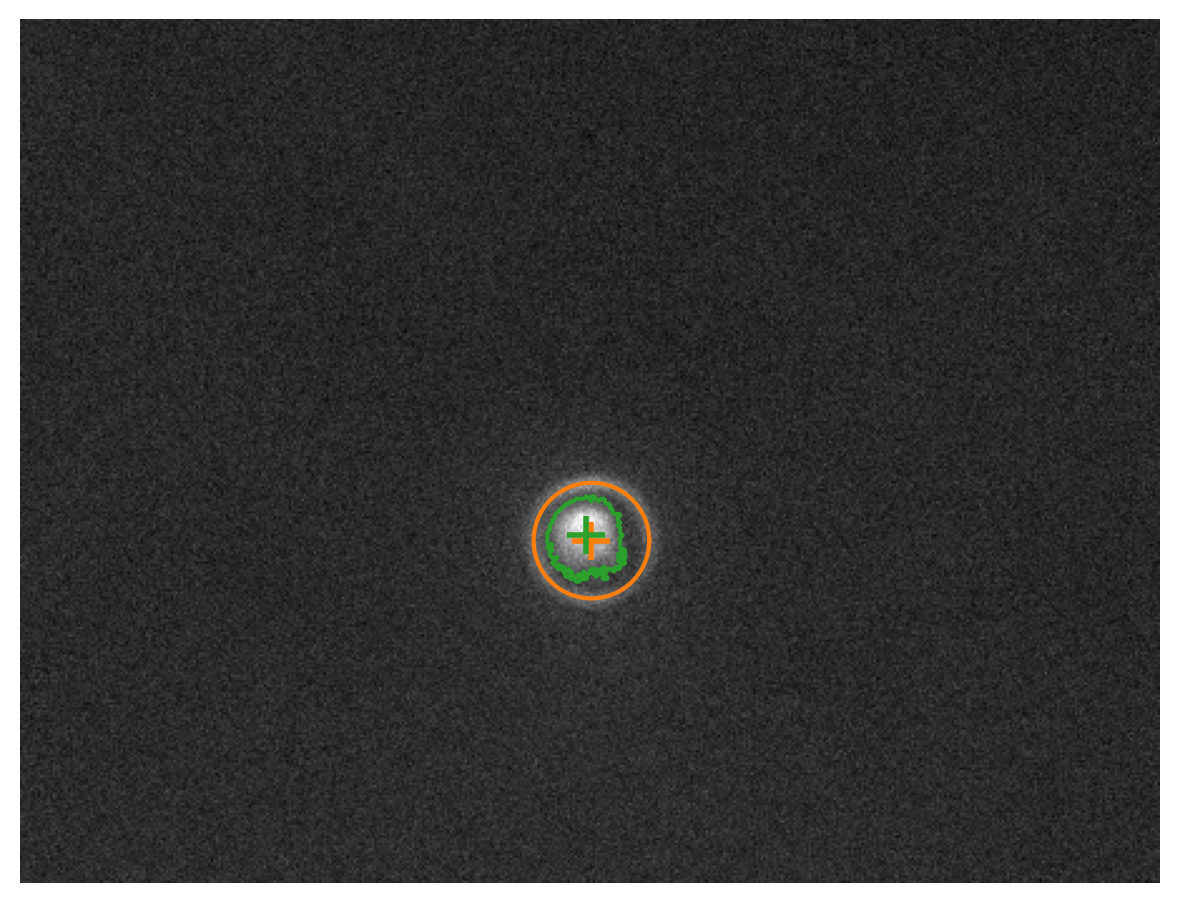

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap='gray')

# --- Shell: Center + ring ---
# center
ax.plot(ring_result['center_x'], ring_result['center_y'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
# Ring
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(ring_result['center_x'] + ring_result['radius'] * np.cos(theta),
        ring_result['center_y'] + ring_result['radius'] * np.sin(theta),
        '-', c='tab:orange', linewidth=1.5, label='ring fit')

# --- inner part: mask outline + center of mass ---
mask = inner_result['mask']
ax.contour(mask, levels=[0.5], colors='tab:green', linewidths=1.5)
ax.plot(inner_result['center_x'], inner_result['center_y'], '+', mec='tab:green', 
        markersize=14, markeredgewidth=2, label='inner COM')


# ax.set_title(f"center=({res['center_x']:.1f}, {res['center_y']:.1f})  "
#              f"r={res['radius']:.1f}px  I={res['intensity_peak']:.1f}")
# ax.legend(loc='upper right', fontsize=8)

ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# from particle_localization import localize_particle

# result = localize_particle(img)

# if result is None:
#     print("No particle found")
# else:
#     print(f"center: ({result['center_x']:.1f}, {result['center_y']:.1f})")
#     print(f"area: {result['area']} px")
#     print(f"equivalent radius: {result['equiv_radius']:.1f} px")

In [11]:
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(img, cmap='gray')

# if result is not None:
#     ax.contour(result['mask'], levels=[0.5], colors='yellow', linewidths=1.5)
#     ax.plot(result['center_x'], result['center_y'], '+', mec='red',
#             markersize=14, markeredgewidth=2, label='center')
#     ax.set_title(f"center=({result['center_x']:.1f}, {result['center_y']:.1f})  "
#                  f"r_eq={result['equiv_radius']:.1f}px")
#     ax.legend(loc='upper right', fontsize=8)

# ax.axis('off')
# plt.tight_layout()
# # plt.savefig('snippet_plot_result.png', dpi=130)
# plt.show()

In [12]:
# from ring_tracker import track_ring

In [13]:
# res = track_ring(img, 131, 70, 28)

In [14]:
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(img, cmap='gray')

# # --- Shell: Center + ring ---
# # center
# ax.plot(res['cx'], res['cy'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
# # # Ring
# # theta = np.linspace(0, 2 * np.pi, 200)
# # ax.plot(ring_result['center_x'] + ring_result['radius'] * np.cos(theta),
# #         ring_result['center_y'] + ring_result['radius'] * np.sin(theta),
# #         '-', c='tab:orange', linewidth=1.5, label='ring fit')

# plt.tight_layout()
# plt.show()

# Inputs

In [143]:
# Where to find the data
path2vid = '/home/nfares/postdoc/experiments/data/Rattler/20260907_rattler_diffusing_DIC_x100_calib_0p04/tototo008_fps_100_p3.tif'

# Frame rate
fps = 79

# Pixel size (in m)
px = 44e-9

# Get the frames 

In [71]:
import re
from pathlib import Path
import tifffile

In [72]:
# ----------------------------------------------------------------------
# A) single multi-page TIFF
# ----------------------------------------------------------------------

def load_multipage_tiff(path):
    """
    Load a multi-page TIFF into a 3D array (n_frames, height, width).
    Works for a single-page tiff too (returns n_frames=1).axes[1].imshow(binary, cmap='gray');  axes[1].set_title('Binary')

    """
    stack = tifffile.imread(path)  # shape (N, H, W) if multi-page, (H, W) if single
    if stack.ndim == 2:
        stack = stack[np.newaxis, ...]
    return stack  # index frames as stack[i]

In [73]:
# ----------------------------------------------------------------------
# B) folder of individual TIFF files (one frame per file)
# ----------------------------------------------------------------------
def _natural_key(path):
    """Sort 'frame2.tif' before 'frame10.tif' (plain sort would do the opposite)."""
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", path.stem)]
 
 
def load_tiff_stack_folder(folder, pattern="*.tif*"):
    """
    Load every TIFF file in a folder, sorted in natural frame order, into a
    list of 2D arrays. Use a list (not a forced np.stack) in case frame
    sizes ever differ; stack yourself with np.stack(frames) if they're all
    the same shape and you want a single 3D array.
    """
    paths = sorted(Path(folder).glob(pattern), key=_natural_key)
    if not paths:
        raise FileNotFoundError(f"No TIFF files found in {folder} matching {pattern}")
    frames = [tifffile.imread(p) for p in paths]
    return frames, paths  # paths returned too, useful for logging/debugging

In [74]:


stack = load_multipage_tiff(path2vid)



In [75]:
print(len(stack))

791


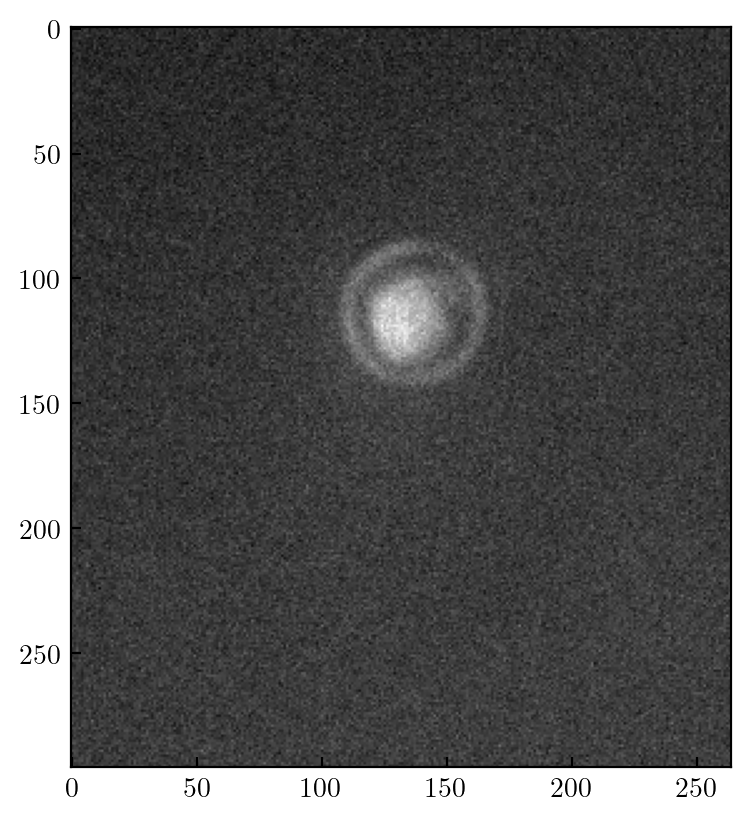

In [76]:
i = 80
plt.imshow(stack[i])

In [77]:
# for i in range(0, 3, 1):
#     plt.imsave('im_' +str(i)+'.png', stack[i])

In [78]:
# plt.imsave('im_' +str(i)+'.png', stack[i])

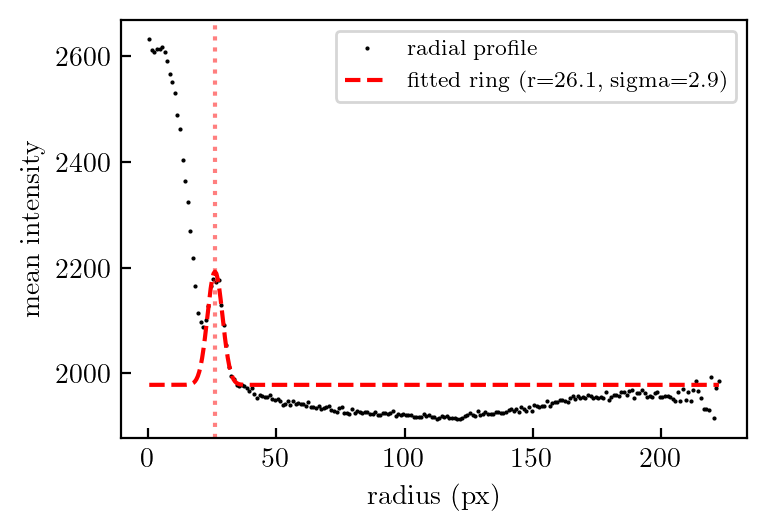

In [101]:
# Test on one image

from ring_tracking import plot_radial_profile

i = 20

frame = stack[i]
    
outer_result = locate_ring(frame, min_snr=2, smoothing_sigma=1.5, range_lower_px=4, range_upper_px=10)

fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

r, profile, fig = plot_radial_profile(frame, result=outer_result, save_path='profile.png', fig=fig, ax=ax)

In [102]:
# outer_result['snr']

In [103]:
# Nim = 100 #len(stack)

start = 0
stop = 50
step = 1

Nim = (stop - start) // step

xsize, ysize = stack[0].shape[::-1]

print(Nim)

50


In [104]:
# # background 

# start_bg = 0 
# stop_bg = Nim
# Nim_bg = 20

# set_images = np.arange(start_bg, stop_bg, (stop_bg - start_bg) // Nim_bg)

# images = []

# for i in tqdm(range(len(set_images))):
#     index = set_images[i]
#     images.append(stack[index])

# bg = np.median(images, axis=0)
# bg[bg == 0] = 1

# del images

In [96]:
# plt.imshow(bg)

In [97]:
def to_uint8(frame, vmin=None, vmax=None):
    frame = frame.astype(np.float64)
    if vmin is None:
        vmin = frame.min()
    if vmax is None:
        vmax = frame.max()
    scaled = (frame - vmin) / (vmax - vmin) * 255
    return np.clip(scaled, 0, 255).astype(np.uint8)

In [105]:
xouter = np.zeros(Nim)
youter = np.zeros(Nim)
Router = np.zeros(Nim)
Souter = np.zeros(Nim)
xinner = np.zeros(Nim)
yinner = np.zeros(Nim)

for i in tqdm(range(start, stop, step)): #, frame in enumerate(stack):

    frame = stack[i]

    j = i - start

    # frame = ((frame.astype(float) - frame.min()) / (frame.max() - frame.min()) * 255).astype(np.uint8)
    # frame = to_uint8(frame)
    
    outer_result = locate_ring(frame, min_snr=2, smoothing_sigma=1.5, range_lower_px=4, range_upper_px=10)
    inner_result = locate_inner_part(frame, outer_result)

    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.imshow(frame, cmap='gray')

    try:
        xouter[j] = outer_result['center_x']
        youter[j] = ysize - outer_result['center_y']
        Router[j] = outer_result['radius']
        Souter[j] = outer_result['sigma']
        xinner[j] = inner_result['center_x']
        yinner[j] = ysize - inner_result['center_y']

        # --- Shell: Center + ring ---
        # center
        ax.plot(outer_result['center_x'], outer_result['center_y'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
        # Ring
        theta = np.linspace(0, 2 * np.pi, 200)
        ax.plot(outer_result['center_x'] + outer_result['radius'] * np.cos(theta),
                outer_result['center_y'] + outer_result['radius'] * np.sin(theta),
                '-', c='tab:orange', linewidth=1.5, label='ring fit')
        
        # --- inner part: mask outline + center of mass ---
        mask = inner_result['mask']
        ax.contour(mask, levels=[0.5], colors='tab:green', linewidths=1.5)
        ax.plot(inner_result['center_x'], inner_result['center_y'], '+', mec='tab:green', 
                markersize=14, markeredgewidth=2, label='inner COM')
        
    except TypeError: 
        print('Bug in the fit of image {}'.format(i))
        # print()
        # print('Modify parameters')
        # print()
        # temp_min_snr = input('Min snr = ? ')
        # temp_smoothing_sigma = input('Smoothing sigma = ? ')
        xouter[j] = np.nan
        youter[j] = np.nan
        Router[j] = np.nan
        Souter[j] = np.nan
        xinner[j] = np.nan
        yinner[j] = np.nan
        
    ax.axis('off')
    
    plt.tight_layout()

    fig.savefig('./temp/image_' + str(i) + '.png')

    plt.close(fig)
    # plt.show()

 80%|██████████████████████████████████████████████████████████▍              | 40/50 [00:09<00:02,  4.05it/s]

Bug in the fit of image 39


 96%|██████████████████████████████████████████████████████████████████████   | 48/50 [00:11<00:00,  4.23it/s]

Bug in the fit of image 47


100%|█████████████████████████████████████████████████████████████████████████| 50/50 [00:11<00:00,  4.38it/s]


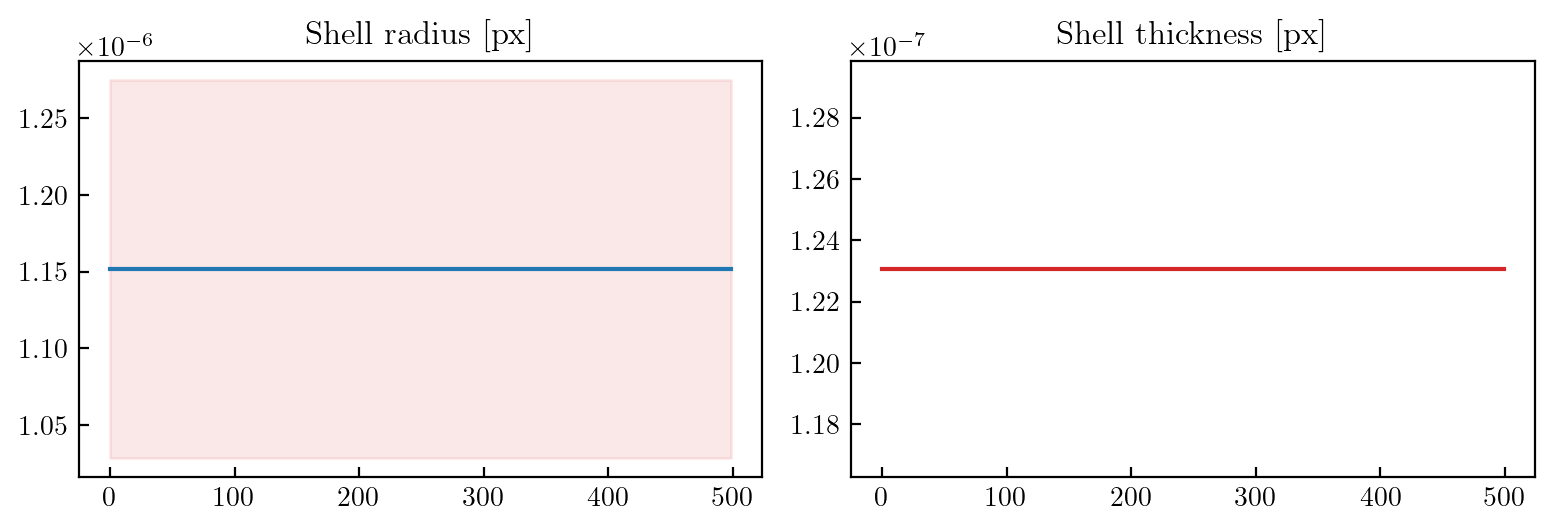

In [212]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(20/2.54, 7/2.54))

cond = Router > 0

ax1.plot(np.arange(len(Router[cond])), Router[cond], ls='-', c='tab:blue')
ax1.fill_between(np.arange(len(Router[cond])), Router[cond] - Souter[cond], Router[cond]+Souter[cond], color='tab:red', alpha=0.1)

ax2.plot(Souter[cond], ls='-', c='tab:red')

ax1.set_title(r'Shell radius [px]')
ax2.set_title(r'Shell thickness [px]')

plt.tight_layout()
plt.show()

In [107]:
# fig.savefig('radii_without_uint8_conversion.pdf')

In [108]:
Rr = np.nanmean(Router)
Sr = np.nanmean(Souter)
print(Rr, Sr)

std_Rr = np.nanstd(Router)
std_Sr = np.nanstd(Souter)

# maybe 2D histogram to choose... Not necessary a priori

26.174099608409936 2.7968685889057743


In [109]:
i = 6
# plt.imshow(stack[i])

# plt.imsave('im_' +str(i)+'.png', stack[i])

# tifffile.imwrite('frame_{}.tif'.format(i), stack[i])

In [110]:
start = 0
stop = 500
step = 1

Nim = (stop - start) // step

print(Nim)

500


In [162]:
xouter = np.zeros(Nim)
youter = np.zeros(Nim)
Router = np.zeros(Nim)
Souter = np.zeros(Nim)
xinner = np.zeros(Nim)
yinner = np.zeros(Nim)

for i in tqdm(range(start, stop, step)): #, frame in enumerate(stack):

    frame = stack[i]

    j = i - start # to match array indexing starting at 0
    
    outer_result = locate_ring(frame, min_snr=2, smoothing_sigma=1.5, range_lower_px=4, range_upper_px=10, fixed_params={"a": Rr, "sigma": Sr})
    inner_result = locate_inner_part(frame, outer_result)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.imshow(frame, cmap='gray')
    
    try: 
        xouter[j] = outer_result['center_x']
        youter[j] = ysize - outer_result['center_y']
        Router[j] = outer_result['radius']
        Souter[j] = outer_result['sigma']
        xinner[j] = inner_result['center_x']
        yinner[j] = ysize - inner_result['center_y']
    
        # --- Shell: Center + ring ---
        # center
        ax.plot(outer_result['center_x'], outer_result['center_y'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
        # Ring
        theta = np.linspace(0, 2 * np.pi, 200)
        ax.plot(outer_result['center_x'] + outer_result['radius'] * np.cos(theta),
                outer_result['center_y'] + outer_result['radius'] * np.sin(theta),
                '-', c='tab:orange', linewidth=1.5, label='ring fit')
        
        # --- inner part: mask outline + center of mass ---
        mask = inner_result['mask']
        ax.contour(mask, levels=[0.5], colors='tab:green', linewidths=1.5)
        ax.plot(inner_result['center_x'], inner_result['center_y'], '+', mec='tab:green', 
                markersize=14, markeredgewidth=2, label='inner COM')

    except TypeError: 
        print('Bug in the fit of image {}'.format(i))
        # print('Modify parameters')
        # print()
        # temp_min_snr = input('Min snr = ? ')
        # temp_smoothing_sigma = input('Smoothing sigma = ? ')
        xouter[j] = np.nan
        youter[j] = np.nan
        Router[j] = np.nan
        Souter[j] = np.nan
        xinner[j] = np.nan
        yinner[j] = np.nan
    
    ax.axis('off')
    
    plt.tight_layout()

    fig.savefig('./temp/image_' + str(i) + '.png')

    plt.close(fig)
    # plt.show()

# Conversion 
xouter = xouter * px
youter = youter * px
Router = Router * px
Souter = Souter * px
xinner = xinner * px
yinner = yinner * px

100%|███████████████████████████████████████████████████████████████████████| 500/500 [01:02<00:00,  8.00it/s]


In [216]:
results = []

for i in tqdm(range(start, stop, step)): #, frame in enumerate(stack):

    frame = stack[i]

    j = i - start # to match array indexing starting at 0
    
    outer_result = locate_ring(frame, min_snr=2, smoothing_sigma=1.5, range_lower_px=4, range_upper_px=10, fixed_params={"a": Rr, "sigma": Sr})
    inner_result = locate_inner_part(frame, outer_result)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.imshow(frame, cmap='gray')
    
    try: 
        row = {
            "frame": i, 
            "time": i / fps, 
            "xs": outer_result["center_x"],
            "ys": ysize - outer_result["center_y"], # to put y in standard human convention
            "as": outer_result["radius"],
            "sigmas": outer_result["sigma"],
            "Is_max": outer_result["intensity_peak"],
            "Is": outer_result["intensity_integrated"],
            "xc": inner_result["center_x"], 
            "yc": ysize - inner_result["center_y"], 
            "Ac": inner_result["area"],
            "Ic": inner_result["intensity_integrated"], 
        }
    
        # --- Shell: Center + ring ---
        # center
        ax.plot(outer_result['center_x'], outer_result['center_y'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
        # Ring
        theta = np.linspace(0, 2 * np.pi, 200)
        ax.plot(outer_result['center_x'] + outer_result['radius'] * np.cos(theta),
                outer_result['center_y'] + outer_result['radius'] * np.sin(theta),
                '-', c='tab:orange', linewidth=1.5, label='ring fit')
        
        # --- inner part: mask outline + center of mass ---
        mask = inner_result['mask']
        ax.contour(mask, levels=[0.5], colors='tab:green', linewidths=1.5)
        ax.plot(inner_result['center_x'], inner_result['center_y'], '+', mec='tab:green', 
                markersize=14, markeredgewidth=2, label='inner COM')

    except TypeError: 
        print('Bug in the fit of image {}'.format(i))
        # print('Modify parameters')
        # print()
        # temp_min_snr = input('Min snr = ? ')
        # temp_smoothing_sigma = input('Smoothing sigma = ? ')
        row = {
            "frame": i, 
            "time": i / fps, 
            "xs": np.nan,
            "ys": np.nan, 
            "as": np.nan,
            "sigmas": np.nan,
            "Is_max": np.nan,
            "Is": np.nan,
            "xc": np.nan, 
            "yc": np.nan, 
            "Ac": np.nan, 
            "Ic": np.nan, 
        }

    results.append(row)
    
    ax.axis('off')
    
    plt.tight_layout()

    fig.savefig('./temp/image_' + str(i) + '.png')

    plt.close(fig)
    # plt.show()


# Convert to pandas DataFrame
results = pd.DataFrame(results)

# Convert values from px to SI units
for col in ("xs", "ys", "as", "sigmas", "xc", "yc"):
    results[col] = results[col] * px
results["Ac"] = results["Ac"] * px ** 2

100%|███████████████████████████████████████████████████████████████████████| 500/500 [01:11<00:00,  7.03it/s]


In [218]:
results.head()

,frame,time,xs,ys,as,sigmas,Is_max,Is,xc,yc,Ac,Ic
0,0,0.000000,0.000006,0.000008,0.000001,1.230622e-07,248.445802,286447.659526,0.000006,0.000008,2.106368e-12,505331.0
1,1,0.012658,0.000006,0.000008,0.000001,1.230622e-07,239.102937,275675.724793,0.000006,0.000008,2.052160e-12,493084.0
2,2,0.025316,0.000006,0.000008,0.000001,1.230622e-07,243.857268,281157.270369,0.000006,0.000008,2.092816e-12,495930.0
3,3,0.037975,0.000006,0.000008,0.000001,1.230622e-07,246.086026,283726.935729,0.000006,0.000008,2.040544e-12,488497.0
4,4,0.050633,0.000006,0.000008,0.000001,1.230622e-07,244.417859,281803.609036,0.000006,0.000008,2.083136e-12,490775.0


In [226]:
xouter = results["xs"].to_numpy()
youter = results["ys"].to_numpy()
Router = results["as"].to_numpy()
Souter = results["sigmas"].to_numpy()
xinner = results["xc"].to_numpy()
yinner = results["yc"].to_numpy()

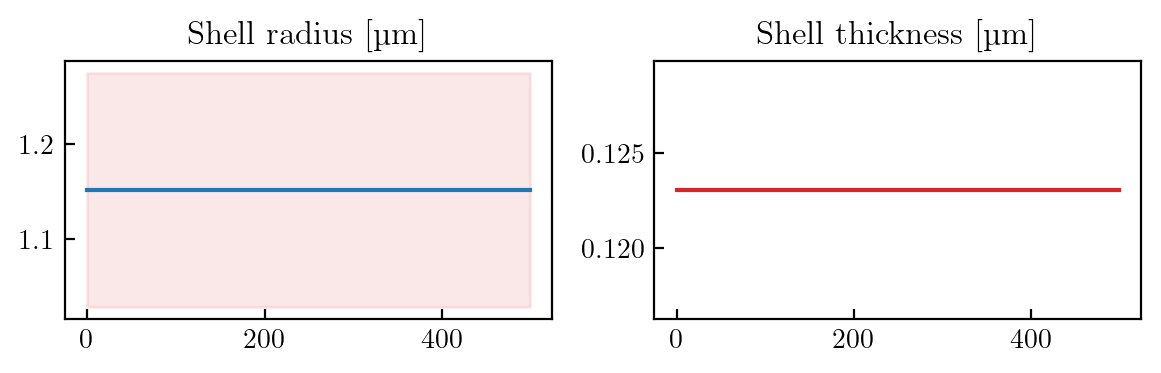

In [219]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15/2.54, 5/2.54))

cond = Router > 0

ax1.plot(np.arange(len(Router[cond])), Router[cond] * 1e6, ls='-', c='tab:blue')
ax1.fill_between(np.arange(len(Router[cond])), (Router[cond] - Souter[cond]) * 1e6, (Router[cond]+Souter[cond]) * 1e6, color='tab:red', alpha=0.1)

ax2.plot(Souter[cond]*1e6, ls='-', c='tab:red')

ax1.set_title(r'Shell radius [\textmu m]')
ax2.set_title(r'Shell thickness [\textmu m]')

plt.tight_layout()
plt.show()

# Quick analysis

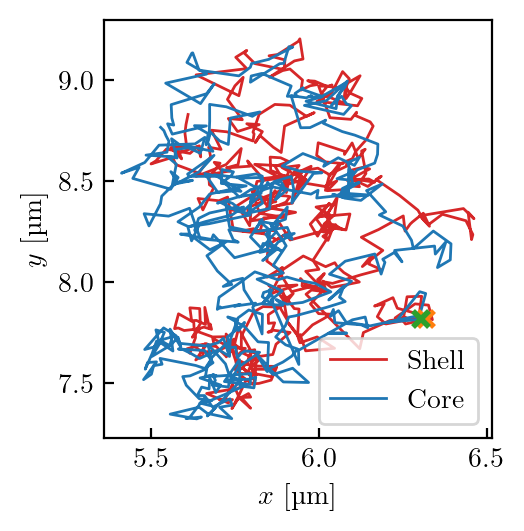

In [173]:
fig, ax = plt.subplots(1, 1, figsize=(7/2.54, 7/2.54))

start = 0
stop = 500
step = 1

ax.plot(xouter[start:stop:step] * 1e6, youter[start:stop:step] * 1e6, ls='-', lw=1, c='tab:red', label='Shell')
ax.plot(xinner[start:stop:step] * 1e6, yinner[start:stop:step] * 1e6, ls='-', lw=1, c='tab:blue', label='Core')

ax.plot(xouter[start]*1e6, youter[start]*1e6, ls='', marker='x', mec='tab:orange', ms=6, mew=2)
ax.plot(xinner[start]*1e6, yinner[start]*1e6, ls='', marker='x', mec='tab:green', ms=6, mew=2)

ax.legend()
ax.set(xlabel=r'$x$ [\textmu m]', ylabel=r'$y$ [\textmu m]')

plt.tight_layout()
plt.show()

In [174]:
def moment(n, x, t, return_std = False, retrieve_mean = False, mean_abs = False):
    """
    Parameters
    ----------
    n: int, moment of order n
    x: array containing the values of interest
    t: an array containing differences of indexes.
    """
    res = np.zeros(len(t))
    std = np.zeros(len(t))
    for i, j in enumerate(t):
        #x_tau = x[j:] - np.mean(x[j:])
        #x_zer = x[0:-j] - np.mean(x[0:-j])
        #res[i] = np.nanmean((x_tau - x_zer)**n)
        Delta_x = x[j:] - x[0:-j]
        if retrieve_mean:
            distribution = (Delta_x - np.mean(Delta_x)) ** n
        else:
            distribution = (Delta_x) ** n
        if mean_abs:
            distribution = np.abs(distribution)
        res[i] = np.nanmean(distribution)
        std[i] = np.nanstd(distribution)
    if return_std:
        return res, std
    else:
        return res

In [175]:
dframes = np.concatenate((np.arange(1, 10, 1), np.arange(10, 100, 2), np.arange(100, 500, 5)))

msdxouter = moment(2, xouter[start:stop:step], dframes, retrieve_mean=False)
msdyouter = moment(2, youter[start:stop:step], dframes, retrieve_mean=False)
msdxinner = moment(2, xinner[start:stop:step], dframes, retrieve_mean=False)
msdyinner = moment(2, yinner[start:stop:step], dframes, retrieve_mean=False)

msdouter = (msdxouter + msdyouter) / 2
msdinner = (msdxinner + msdyinner) / 2

msdxboth = moment(2, xinner[start:stop:step]-xouter[start:stop:step], dframes, retrieve_mean=False)
msdyboth = moment(2, yinner[start:stop:step]-youter[start:stop:step], dframes, retrieve_mean=False)

msdboth = (msdxboth + msdyboth) / 2

dtimes = dframes / fps

In [176]:
fps

79

In [177]:
path = '../../data/Rattler/20260908_rattler_diffusing_withPEG_DIC/trajectories_ole010_fps_50_p3_no_shell'

fps_noshell = 50

df = pd.read_pickle(path)

df.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,0.000007,0.000008,338672.735661,9.928192,0.067487,779.848921,2736211.0,NaN,0,0
1,0.000007,0.000008,328891.080129,9.847819,0.076494,745.035280,2719112.0,NaN,1,0
2,0.000007,0.000008,331996.299335,9.889371,0.086166,739.319729,2719952.0,NaN,2,0
3,0.000007,0.000008,337085.122987,9.992001,0.089100,728.141875,2734455.0,NaN,3,0
4,0.000007,0.000008,337437.360208,9.924857,0.088754,771.804942,2734975.0,NaN,4,0


In [178]:
xnoshell = df['x'].to_numpy()
ynoshell = df['y'].to_numpy()

msdxnoshell = moment(2, xnoshell, dframes, retrieve_mean=False)
msdynoshell = moment(2, ynoshell, dframes, retrieve_mean=False)

msdnoshell = (msdxnoshell + msdynoshell) / 2

dtimes_noshell = dframes / fps_noshell

In [179]:
# path2 = '../../data/Rattler/20260908_rattler_diffusing_withPEG_DIC/trajectories_ole011_fps_50_p3_no_shell'

# df2 = pd.read_pickle(path2)

# # df2.head()

# xnoshell2 = df2['x'].to_numpy()
# ynoshell2 = df2['y'].to_numpy()

# msdxnoshell2 = moment(2, xnoshell2, dframes, retrieve_mean=False)
# msdynoshell2 = moment(2, ynoshell2, dframes, retrieve_mean=False)

# msdnoshell2 = (msdxnoshell2 + msdynoshell2) / 2

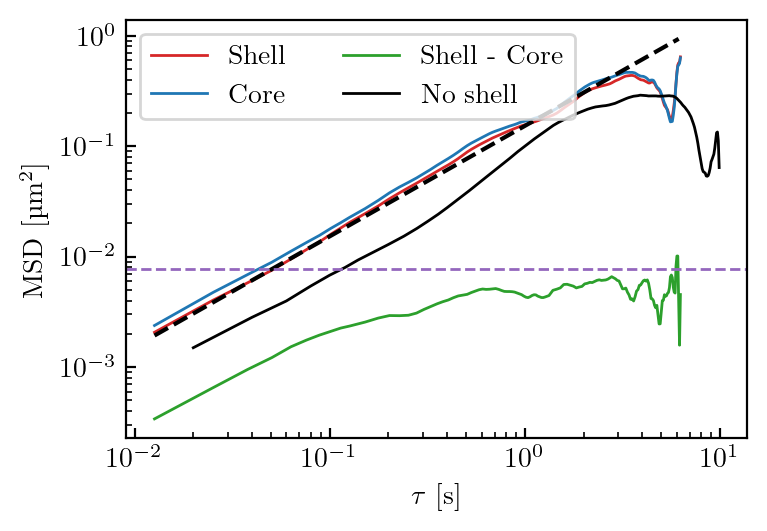

In [186]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

ax.plot(dtimes, msdouter * 1e12, ls='-', lw=1, c='tab:red', label='Shell')
# ax.plot(dtimes, msdouter * 1e12, ls='', marker='o', c='tab:red', label='Shell')
ax.plot(dtimes, msdinner * 1e12, ls='-', lw=1, c='tab:blue', label='Core')
ax.plot(dtimes, msdboth * 1e12, ls='-', lw=1, c='tab:green', label='Shell - Core')

ax.plot(dtimes_noshell, msdnoshell * 1e12, ls='-', lw=1, c='k', label='No shell')
# ax.plot(dtimes_noshell, msdnoshell2 / (px**2), ls='-.', lw=1, c='k', label='No shell')

# ax.plot(dtimes[2:-2], 100 * dtimes[2:-2], ls='--', c='k')
ax.plot(dtimes[:-2], 2 * 0.36 * (4e-21) / (6*np.pi*0.001*1e-6) * dtimes[:-2] * 1e12, ls='--', c='k')

ax.axhline(y=(2*px)**2 * 1e12, ls='--', c='tab:purple', lw=1)

ax.legend(loc='upper left', ncol=2)
ax.set(xlabel=r'$\tau$ [s]', ylabel=r'MSD [\textmu$\mathrm{m^2}$]', xscale='log', yscale='log')

plt.tight_layout()
plt.show()

In [182]:
# fig.savefig()

In [187]:
plateau_MSD = np.nanmean(msdboth[(dtimes > 1) & (dtimes < 5)])
print(plateau_MSD)
print(np.sqrt(5/2 * plateau_MSD) * 1e9)

5.06343025033895e-15
112.51033564009741


In [135]:
def pdf(data, bins=10, density=True, range=None):
    pdf, bins_edge = np.histogram(
        data, 
        bins=bins, 
        density=density, 
        range=range, 
    )
    bins_center = (bins_edge[0:-1] + bins_edge[1:]) / 2
    return pdf, bins_center

In [189]:
rr = np.sqrt((xinner[start:stop:step] - xouter[start:stop:step]) ** 2 + (yinner[start:stop:step] - youter[start:stop:step]) ** 2)

# rr = rr[:100]

In [192]:
Pr, bins_Pr = pdf(rr, bins=30, range=[0,300e-9])

/tmp/ipykernel_94245/2066733977.py:3: RuntimeWarning: divide by zero encountered in log
  ax.plot(bins_Pr*1e9, -np.log(Pr), ls='', marker='o')


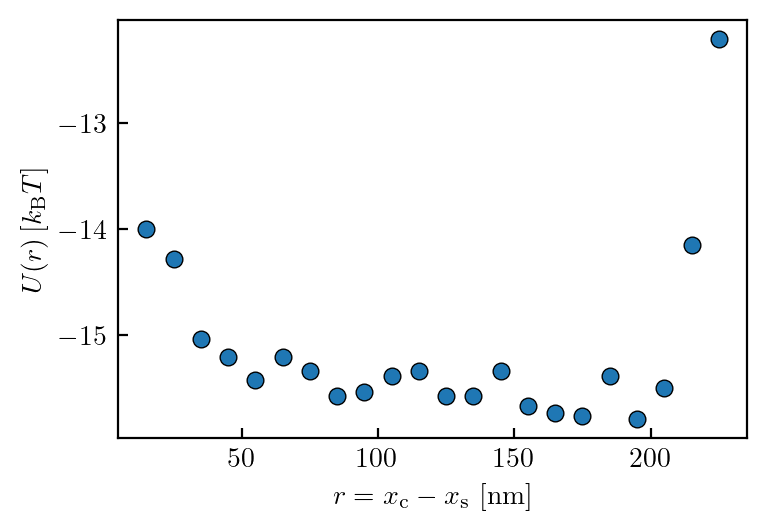

In [202]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

ax.plot(bins_Pr*1e9, -np.log(Pr), ls='', marker='o')

ax.set(yscale='linear', xscale='linear', xlabel=r'$r = x_\mathrm{c} - x_\mathrm{s}$ [nm]', ylabel=r'$U(r) \, [k_\mathrm{B}T]$')

plt.tight_layout()
plt.show()

In [203]:
print(max(rr))

2.242118319187326e-07


In [204]:
len(rr[np.isnan(rr)])

0

In [207]:
np.isfinite(np.log(Pr)[0])

/tmp/ipykernel_94245/267393109.py:1: RuntimeWarning: divide by zero encountered in log
  np.isfinite(np.log(Pr)[0])


np.False_

In [129]:
# ── Wiener-Khinchin (via autocorrelation) ──────────────────────────────
def autocorrelation_biased(a):
    a = a - np.mean(a)
    N = len(a)
    f = np.fft.rfft(a, n=2*N)
    acf = np.fft.irfft(f * np.conj(f))[:N]
    acf /= N  # divide by N instead of N-lag
    return acf
    
def compute_psd(a, dt):
    x_detrended = a #signal.detrend(a, type='linear')
    acf = autocorrelation_biased(x_detrended)
    psd_wk = np.fft.rfft(acf) * dt
    freqs_wk = np.fft.rfftfreq(len(acf), d=dt)
    return freqs_wk, psd_wk

In [130]:
freqs_outer, psd_xouter = compute_psd(xouter, dt=1/fps)
_, psd_youter = compute_psd(youter, dt=1/fps)

freqs_inner, psd_xinner = compute_psd(xinner, dt=1/fps)
_, psd_yinner = compute_psd(yinner, dt=1/fps)

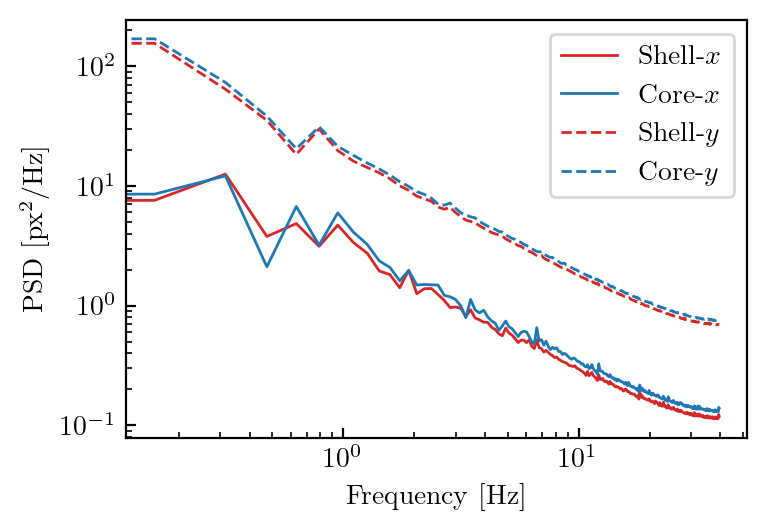

In [131]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

ax.plot(freqs_outer, np.abs(psd_xouter), ls='-', lw=1, c='tab:red', label='Shell-$x$')
ax.plot(freqs_inner, np.abs(psd_xinner), ls='-', lw=1, c='tab:blue', label='Core-$x$')

ax.plot(freqs_outer, np.abs(psd_youter), ls='--', lw=1, c='tab:red', label='Shell-$y$')
ax.plot(freqs_inner, np.abs(psd_yinner), ls='--', lw=1, c='tab:blue', label='Core-$y$')

ax.legend()
ax.set(xlabel='Frequency [Hz]', ylabel=r'PSD [$\mathrm{px^2/Hz}$]', xscale='log', yscale='log')

# plt.ylim([1e-22, None])

plt.tight_layout()
plt.show()

In [132]:
def crosscorrelation_biased(a, b, dt):
    
    assert len(a) == len(b)
    
    a = a - np.mean(a)
    b = b - np.mean(b)
    N = len(a)

    fa = np.fft.rfft(a, n=2*N)
    fb = np.fft.rfft(b, n=2*N)

    # # cross-power spectrum: conj(fa) * fb gives corr(a,b) with b shifted forward
    # ccf = np.fft.irfft(np.conj(fa) * fb, n=2*N)
    # ccf /= N  # biased normalization, same convention as your acf

    # # reorder: irfft gives [lag 0, 1, ..., N-1, -(N), ..., -1]
    # # rearrange to [-(N-1), ..., -1, 0, 1, ..., N-1]
    # ccf = np.concatenate((ccf[-(N-1):], ccf[:N]))

    # lags = np.arange(-(N-1), N)
    # lags = lags * dt

    # cross-power spectrum: conj(fa) * fb gives corr(a,b) with b shifted forward
    ccf = np.fft.irfft(np.conj(fa) * fb, n=2*N)[:N]
    ccf /= N  # biased normalization, same convention as your acf

    lags = np.arange(0, N)
    lags = lags * dt
    
    return lags, ccf

In [133]:
lags_x, ccf_x = crosscorrelation_biased(xouter, xinner, dt=1/fps)
lags_y, ccf_y = crosscorrelation_biased(youter, yinner, dt=1/fps)

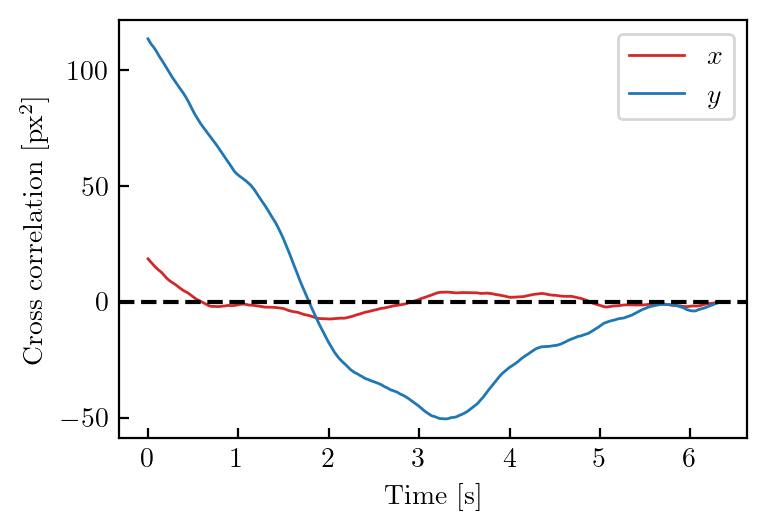

In [134]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

ax.plot(lags_x, ccf_x, ls='-', lw=1, c='tab:red', label='$x$')
ax.plot(lags_y, ccf_y, ls='-', lw=1, c='tab:blue', label='$y$')

ax.axhline(y=0, ls='--', c='k')

ax.legend()
ax.set(xlabel='Time [s]', ylabel=r'Cross correlation [$\mathrm{px^2}$]', xscale='linear', yscale='linear')

plt.tight_layout()
plt.show()